In [1]:
import math
import multiprocessing
from multiprocessing import Pool
# import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import fnmatch
import sys
import re
import joblib

from tqdm.notebook import tqdm


In [2]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import math

In [3]:

from itertools import combinations
import time
from shapely.ops import unary_union
from shapely.geometry import Point
from shapely.geometry import Point, Polygon
from functools import reduce
import pickle

In [4]:
from tqdm.notebook import tqdm

In [5]:
import seaborn as sns
from collections import defaultdict
from collections import Counter

In [6]:
pwd

'/glade/u/home/qingyuany/cam7_v1'

In [7]:
%run ./common_vars.py
%run ./funs/plotting.py
%run ./funs/utils.py

In [9]:
meta = pd.read_csv("/glade/work/qingyuany/cam7_tuning/cam7/meta/meta_cli_para.csv", index_col = 0)
tf_masks_raw = pd.read_csv("/glade/work/qingyuany/cam7_tuning/cam7/zonal_masks_2.0.csv", index_col=0)
para_emu = xr.open_dataset("/glade/work/qingyuany/cam7_tuning/cam7/sample_para/para_sample_v1.nc").to_dataframe()
para_nm = list(para_emu.columns)

In [ ]:
meta['PRECT_zonal_lat_-52']

## Filter variables to ignore

In [10]:
polar_vars = [localvar for localvar in list(tf_masks_raw.columns) if ((localvar.split("_")[1] == "zonal") | 
                                                        (localvar.split("_")[2] == "zonal")) & 
                                                        (abs(float((localvar.split("_")[-1]))) > 80) ]

useless_vars = list(tf_masks_raw.columns[tf_masks_raw.sum(axis = 0) == 1000000])
manual_remove_vars = list(tf_masks_raw.columns[tf_masks_raw.columns.str.startswith("CLDTOT_ISCCP_zonal")]) + list(tf_masks_raw.columns[tf_masks_raw.columns.str.startswith("TGCLDLWP_zonal")])





In [11]:
len(manual_remove_vars)

34

In [12]:
para_emu.shape

(1000000, 38)

In [13]:
len(polar_vars)

20

In [14]:
ignore_vars = polar_vars + useless_vars + manual_remove_vars

In [15]:
tf_masks_raw = tf_masks_raw.drop(columns = ignore_vars, errors = "ignore")#

In [16]:
strt_threshold = 100000
strt_vars = list(tf_masks_raw.columns[((tf_masks_raw.sum(axis = 0) < strt_threshold))])

In [17]:
strt_vars.sort()

In [18]:
tf_masks_raw = tf_masks_raw.drop(columns = strt_vars)


## Group the and filter more variables based on emulator meta data

In [19]:
# rm_3d_var = ['LHFLX_24_50_235_293', 'LHFLX_zonal_lat_37', 'LWCF_zonal_lat_-72', 'LWCF_zonal_lat_-37', 'LHFLX_24_50_235_293', 'LWCF_zonal_lat_-77', 'LWCF_zonal_lat_-32', 'PRECT_zonal_lat_-22',
#             'FSNT_24_50_235_293', 'SWCF_24_50_235_293', 'LHFLX_zonal_lat_-72', 'FSNT_zonal_lat_77', 'PRECT_zonal_lat_-7', 'LHFLX_zonal_lat_67',
#              'PRECT_zonal_lat_-47', 'PRECT_zonal_lat_-17', 'TMQ_zonal_lat_-42', 'TMQ_zonal_lat_-47', 'TMQ_zonal_lat_-37', 'PRECT_zonal_lat_67', 'RESTOM_zonal_lat_-32', 
#              'TMQ_zonal_lat_-67']

rm_3d_var = []

tf_masks = tf_masks_raw.drop(columns = rm_3d_var)

In [20]:
paras_vars, strt_paras_vars, surv_paras_vars = group_para_climatology(para_emu, tf_masks, meta, threshold = 100000)

In [21]:
strterr_sum =  strterr_detection(strt_paras_vars, tf_masks, n_comb = 2)

  0%|          | 0/6 [00:00<?, ?it/s]

In [28]:
list(strterr_sum.values())[2].head(30)


,var1,var2,count
103,TMQ_zonal_lat_-42,FSNT_zonal_lat_-22,0
82,RESTOM_zonal_lat_-32,TMQ_zonal_lat_-42,0
57,TMQ_zonal_lat_-47,SWCF_zonal_lat_-27,0
58,TMQ_zonal_lat_-47,TGCLDLWP_-5_5_210_270,0
61,TMQ_zonal_lat_-47,FSNT_zonal_lat_-37,0
49,TMQ_zonal_lat_-47,FSNT_zonal_lat_-22,0
112,TMQ_zonal_lat_-42,TGCLDLWP_-5_5_210_270,0
62,TMQ_zonal_lat_-47,SWCF_zonal_lat_-22,0
50,TMQ_zonal_lat_-47,RESTOM_zonal_lat_-42,0
51,TMQ_zonal_lat_-47,FSNT_zonal_lat_-32,0


In [55]:
list(strterr_sum.keys())[2]

('clubb_c14', 'micro_mg_accre_enhan_fact')

In [40]:
para1_vars_dict, para1_para2_dict, para1_ranges = range_err_detection2(surv_paras_vars, tf_masks, para_emu, meta)

Empty DataFrame
Columns: [min, max]
Index: []


In [36]:
vtrim_factor_dict = {}
for v in sorted(para1_vars_dict["micro_mg_vtrmi_factor"]):
    if para_emu[tf_masks[v]].micro_mg_vtrmi_factor.min()> 0.05:
        vtrim_factor_dict[v] = para_emu[tf_masks[v]].micro_mg_vtrmi_factor.min()

In [37]:
vtrim_factor_dict

{'FLNT_zonal_lat_-72': 0.48333305170739105,
 'PRECT_zonal_lat_72': 0.125165875028714,
 'RESTOM_zonal_lat_-67': 0.19593960124479703,
 'TMQ_zonal_lat_47': 0.19755773417317524,
 'TMQ_zonal_lat_52': 0.42089981512182695}

In [21]:

for k, v in paras_vars.items():
    paras_vars[k] = sorted(paras_vars[k])


In [23]:
def get_bin(lat):
    # Compute 5-degree bin start correctly for negatives
    
    low = (lat // 5) * 5
    high = low + 5
    return f"{low}:{high}"

In [29]:
obs_dict = {'RESTOM': 'toa_net_all_mon',
 'FSNT': 'fsnt',
 'FLNT': 'toa_lw_all_mon',
 'SWCF': 'toa_cre_sw_mon',
 'LWCF': 'toa_cre_lw_mon',
 'PRECT': 'PRECT',
 'TGCLDLWP': 'TGCLDLWP',
 'FLUTC': 'toa_lw_clr_t_mon',
 'FSNTC': 'toa_sw_clr_t_mon',
 'TMQ': 'PREH2O',
 'LHFLX': 'LHFLX'}


del obs_dict['FLUTC']
del obs_dict['FSNTC']


In [30]:

def para_var_org(list_vars, voi):    
    records = []
    
    for s in list_vars:
    
        # Skip anything without "zonal"
        if "_zonal_" not in s:
            continue
    
        var = s.split("_")[0]  # before _zonal_
        lat = int(re.search(r'lat_(-?\d+)', s).group(1))
        lat_bin = get_bin(lat)
    
        records.append((var, lat_bin))
    
    
    df = pd.DataFrame(records, columns=["var", "lat_bin"])
    df["value"] = 1
    
    pivot = df.pivot_table(index="var", columns="lat_bin",
                           values="value", fill_value=0)
    
    all_bins = [f"{i}:{i+5}" for i in range(-90, 90, 5)]
    pivot = pivot.reindex(columns=all_bins, fill_value=0)
    pivot = pivot.reindex(voi,fill_value=0)
    return pivot


In [33]:
par_var_visual = {}
for k, v in paras_vars.items():
    par_var_visual[k] = para_var_org(paras_vars[k], list(obs_dict.keys()))
    


    



In [42]:
useless_visual = para_var_org(useless_vars, list(obs_dict.keys()))

useless_visual = useless_visual.stack()
useless_visual = useless_visual[useless_visual!=0]
useless_visual = useless_visual.reset_index()
useless_visual['lat_bin'] = pd.Categorical(useless_visual['lat_bin'], categories=[f"{i}:{i+5}" for i in range(-90, 90, 5)], ordered=True)


In [48]:
strt_visual = para_var_org(strt_vars, list(obs_dict.keys()))
strt_visual = strt_visual.stack()
strt_visual = strt_visual[strt_visual!=0]
strt_visual = strt_visual.reset_index()
strt_visual['lat_bin'] = pd.Categorical(strt_visual['lat_bin'], categories=[f"{i}:{i+5}" for i in range(-90, 90, 5)], ordered=True)



In [52]:
rm_visual = para_var_org(rm_3d_var, list(obs_dict.keys()))
rm_visual = rm_visual.stack()
rm_visual = rm_visual[rm_visual!=0]
rm_visual = rm_visual.reset_index()
rm_visual['lat_bin'] = pd.Categorical(rm_visual['lat_bin'], categories=[f"{i}:{i+5}" for i in range(-90, 90, 5)], ordered=True)


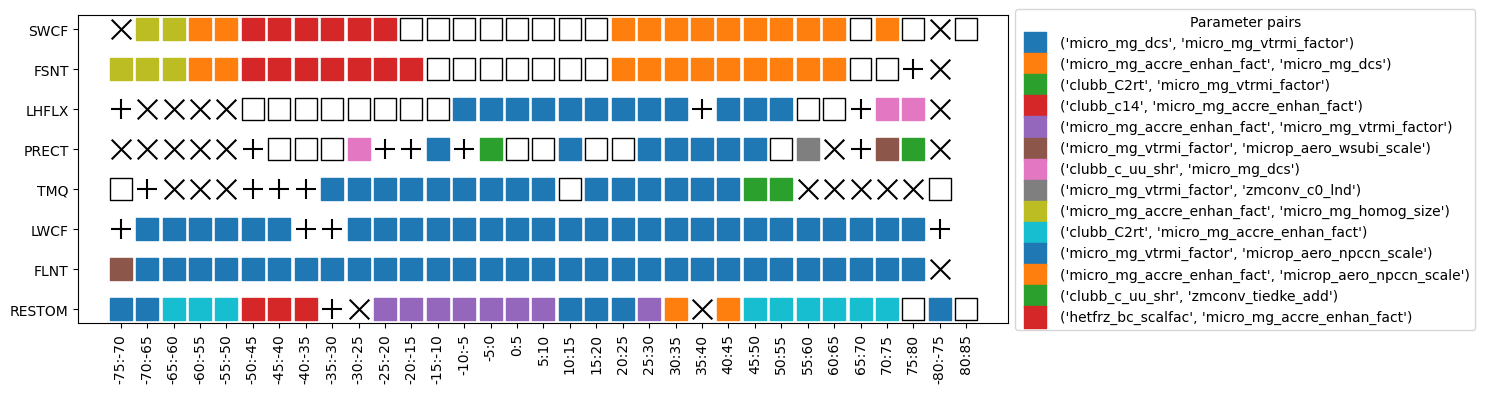

In [86]:

all_bins = [f"{i}:{i+5}" for i in range(-90, 90, 5)]

plt.figure(figsize=(12, 4))
for i, (k, v) in enumerate(par_var_visual.items()):
    v = v.stack()
    v = v[v!=0]
    v = v.reset_index()
    v['lat_bin'] = pd.Categorical(v['lat_bin'], categories=[f"{i}:{i+5}" for i in range(-90, 90, 5)], ordered=True)
    v = v.sort_values('lat_bin')
    if v.shape[0] > 0:    
        plt.scatter(v["lat_bin"], v["var"], label = k, s = 250, marker = 's');
        plt.xticks(rotation=90)
        

plt.scatter(useless_visual["lat_bin"], useless_visual["var"], s = 250, marker = 's', facecolors='none', edgecolors='black');
plt.scatter(strt_visual["lat_bin"], strt_visual["var"], s = 200, marker = 'x', color ='black');
plt.scatter(rm_visual["lat_bin"], rm_visual["var"], s = 200, marker = '+', color ='black');


plt.legend(title="Parameter pairs", bbox_to_anchor=(1, 0.5), loc='center left')

In [62]:
para_os = pd.read_csv("/glade/work/qingyuany/cam7/para/ppe0_original_scale.csv", index_col=0)
est_para = pd.read_csv("/glade/work/qingyuany/cam7/est_paras_scale20_original_scale.csv", index_col=0)


In [64]:
2 ** 3

8

In [75]:
cam6_default = {
    "micro_mg_vtrmi_factor": 1.0,
    "micro_mg_accre_enhan_fact": 1.0,
    "micro_mg_homog_size": 2.5 * 10 ** (-5),
    'micro_mg_dcs': 5 * 10 ** (-4),
    'clubb_c14': 2.20,
    'clubb_C2rt': 1.0,
    'microp_aero_wsubi_scale': 1.0,
    'microp_aero_npccn_scale': 1.0,
    'zmconv_c0_lnd':  0.0075
}

In [79]:
sel_para = ["micro_mg_vtrmi_factor", "micro_mg_accre_enhan_fact", "micro_mg_dcs", "micro_mg_homog_size", "clubb_c14", "clubb_C2rt", "clubb_c_uu_shr", "zmconv_c0_lnd", "microp_aero_wsubi_scale", "microp_aero_npccn_scale"]

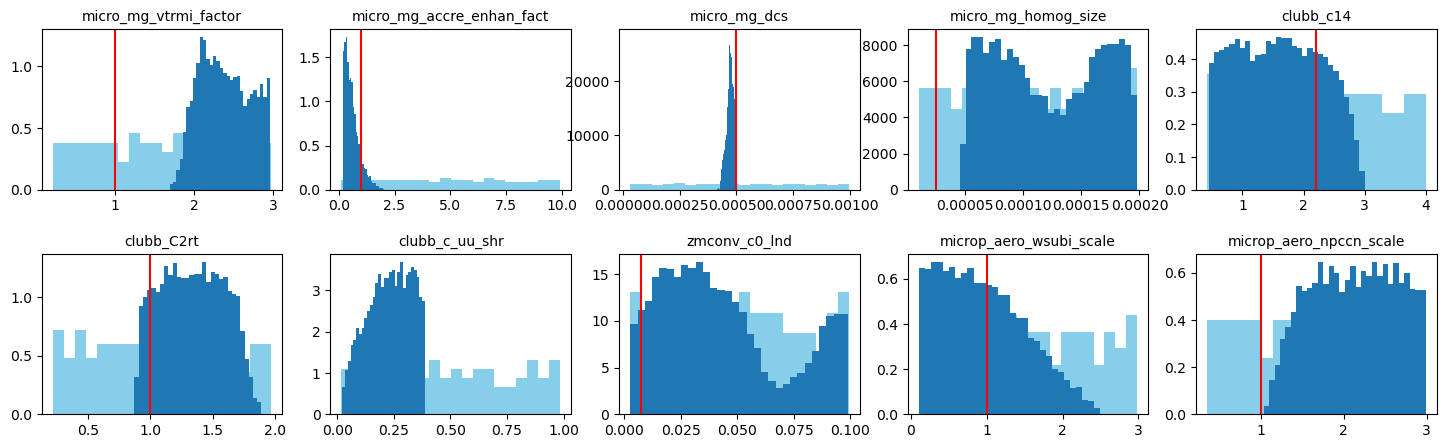

In [85]:
fig, axes = plt.subplots(nrows=2, ncols=5 , figsize=(18, 5))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

axes = axes.flatten()

for i, col in enumerate(sel_para):
    axes[i].hist(para_os[col], bins=20, density=True, color='skyblue')
    axes[i].hist(est_para[col], bins=30, density=True)
    if col in cam6_default:
        axes[i].axvline(cam6_default[col], color = 'red')
    axes[i].set_title(col, fontsize=10)
    